## California Housing Prices (regression), dataset evaluation report 
#### (https://www.kaggle.com/datasets/camnugent/california-housing-prices)<br>Target variable is "median_house_value" (continuous, regression).<br>Price range is 14 999 - 500 001 USD.

### Variables to drop or to process further<br>
- longitude, latitude - will be dropped as coordinates are not good for ML model (based on coordinates I created a new column "distance_to_nearest_city" to use in the evaluation)<br>
- ocean_proximity - categorical variable. Will be processed using encoder.<br>

#### This is the path to dataset preparation file: Exercise_project_1\Regression_dataset\dataset preparation.ipynb


### Rest of the variables

- "housing_median_age",
- 'total_rooms', 
- 'total_bedrooms', 
- 'population',
- 'households', 
- 'median_income',


###  Variable importance and redundancy analysis, missing values

#### According to ydata-profiling there are missing values in "total_bedrooms" variable. As we have 20640 of rows we can just drop rows with missing value.<br>VIF-test for multicollinearity<br>median_house_value has positive correlation with "median_income" and negative correlation with "ocean_proximity_INLAND" and "distance_to_nearest_city" (Source: dataset_preparation.ipynb)<br>Based on correlation matrix and VIF test there is multicollinearity + redundancy: total_rooms, total_bedrooms, and households, population:
- total_rooms and total_bedrooms : these two are strongly linearly related — houses with more rooms usually have more bedrooms.<br>
- households and  population: population ≈ households× avg_people_per_household - these two variables carry kinda similar information and they produce high correlation and high VIF
- ocean_proximity_<1H OCEAN and ocean_proximity_INLAND: These are one-hot encoded variables.

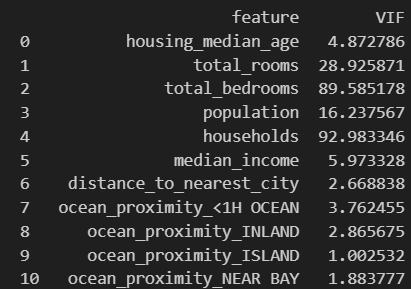 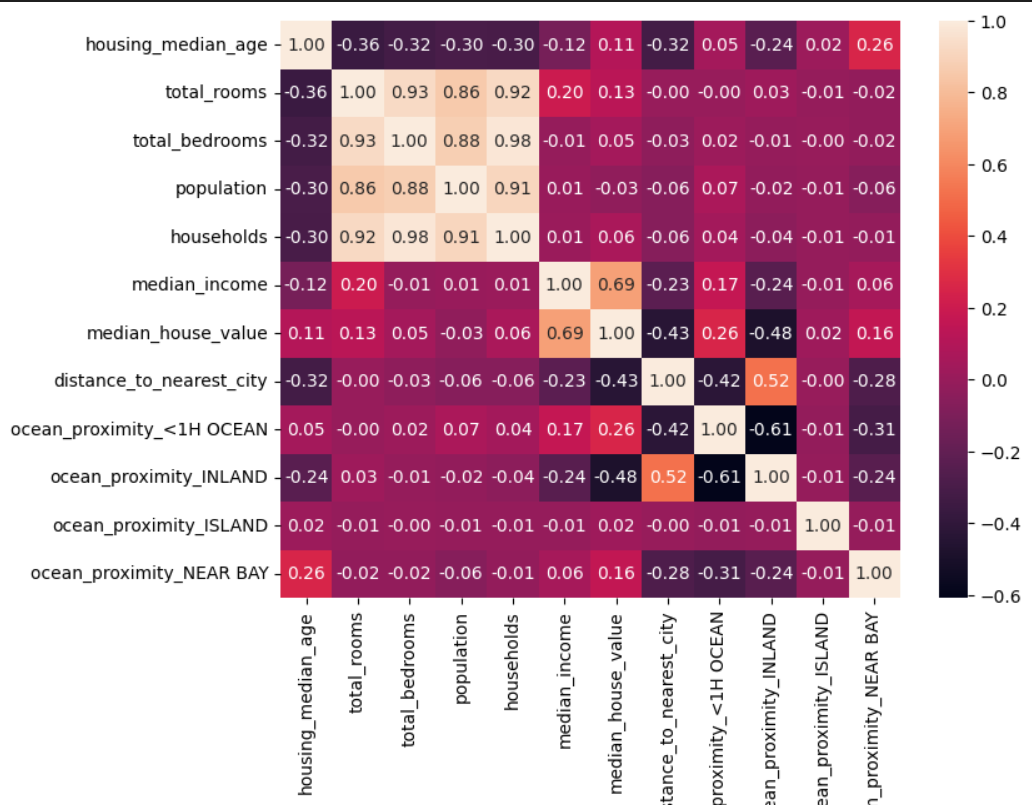

#### Options to do:
- drop "total_bedrooms" and preserve "total_rooms". Also drop "households" and preserve "population". And we can cosider to remove one encoded variable, for example one with highest VIF-test score "ocean_proximity_<1H OCEAN"
- we can combine variables: "rooms_per_household" = "total_rooms" /"households"
"bedroom_share" = "total_bedrooms" / "total_rooms", "population_per_household" = "population" / "households" (basically this would tell How many people live in an average household?)

### Distributions

#### Target variable (median_house_value) distribution. Not a normal distribution.
- Most houses are clustered between 100,000–250,000.
- we can seee a huge spike at 500,001, probably the “luxury” tail of the price distribution is compressed into one single value. Actually, the dataset hides the true prices of expensive houses. This is bad for ML model because a model will never predict values much higher than 500,001

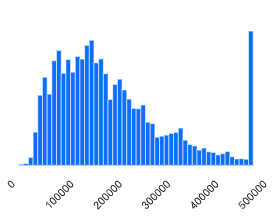

#### Fix options:
- use quantiles to remove the top % in order to get closer to normal distribution
- Offered but ChatGPT: Log transformation, Winsorization (capping extreme values instead of deleting), Robust scaling (for ML models), Box–Cox or Yeo–Johnson transformations

#### Support variable distributions
- housing_median_age: similar to target variable. We can see a Large spike at the right edge (age = 52). That bump means many houses have a "housing median age" of 52, which is the maximum possible value_ probable all house_median ages > 52 years were capped at 52.
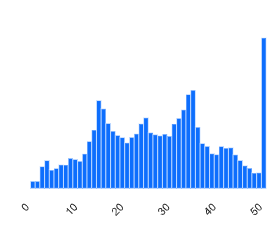
- total_rooms, total_bedrooms, population and households variable have a long tail. Earlier I suggested to drop some of these variables or to combine. The tail probable still will exist even with combined/new variables. That long tail is not good for ML models, it would be better to compresses the right tail and makes the distribution more normal-like.<br>

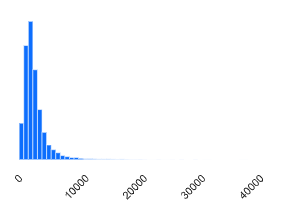 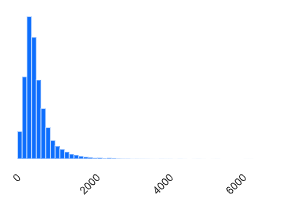<br>
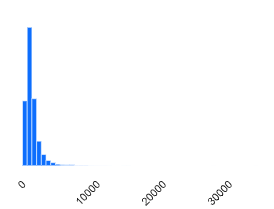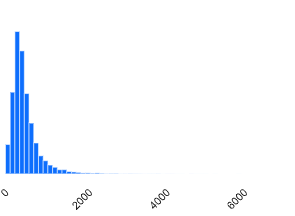
- distance_to_nearest_city (this variable was created from lon, lat variables): most observations are very close to a city; most values are very close to a city (0–100); the tail gradually thins out, meaning most areas are urban or suburban. To make distibution better can be used Log-transform, Square-root transform Quantile transformation or many other technics as suggested by CharGPT.
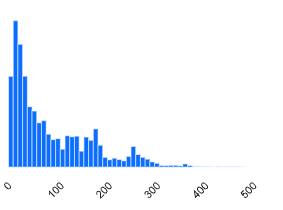
- median_income: has strong correlations with target variable. As areas with higher household income tend to have significantly higher house prices. Distribution is not that bad but still has a tail meaning many moderate-income areas and fewer high-income ones. A tail representing a small number of very high-income districts. ChatGPT suggest to keep as it is and use tree-based models (RandomForest, XGBoost, etc.) that handle mild skew fine. Or use Log-transform method ot other.
 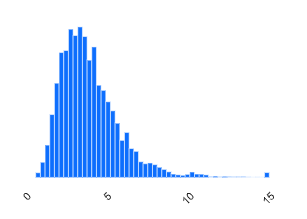

### Data imbalances
#### Variaables "total_rooms", "total_bedrooms", "population", "households" are imbalanced due to a long tails. Majority of data is in the low value range. A few values are very large, that's why we see these long tails.<br>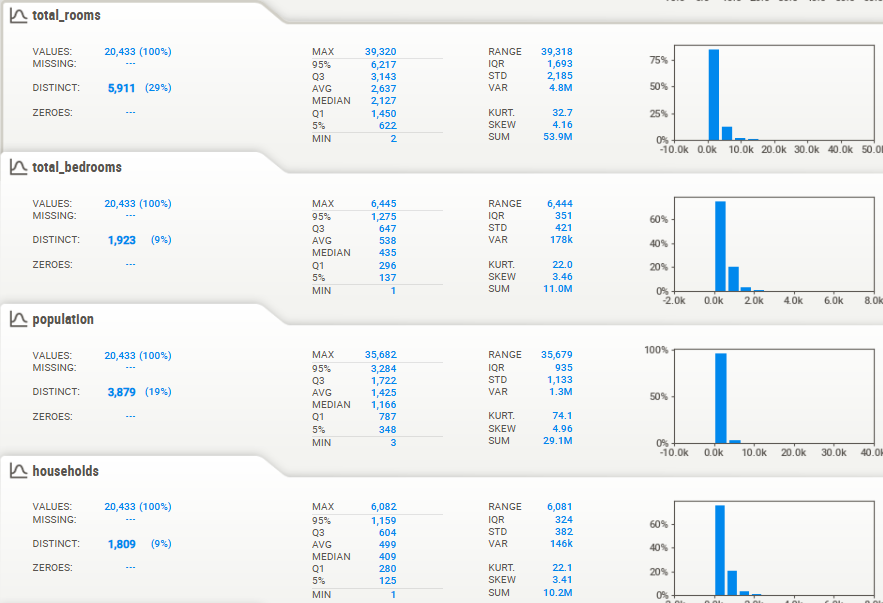
#### Fix options:
- As it was said is it good to combine these variables or to delete some, then the distribution will be still imbalanced, so it will be needed to remove high value outliers using quantile filtering
- Under-/oversampling techniques + synthesize will not work because there we have not so many high values that create long tail. If we do the data will have too many unrealistic synthetic values. <br>
#### median_house_value - target variable. High-value homes are underrepresented.
Fix option: 
- Consider quantile filtering<br>
#### housing_median_age variable has the same problem as target variable. I would fix it using the same method as target variable.<br>
#### ocean_proximity (categorical). Bar chart shows imbalance in categories: <1H OCEAN dominates and ISLAND is very rare. Rare categories may be ignored by the model<br>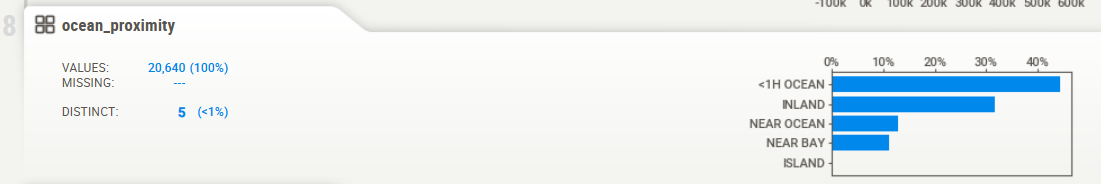
#### Option to fix:
- One-hot encode
- Good to check if rare classes skew results or introduce variance
- maybe consider grouping rare classes
#### distance_to_nearest_city.Very high concentration on the left (close distances (0–100) dominate), far distances are rare but present.<br> ![
](attachment:image-3.png)
#### Options to fix:
- Log-transform
- Binning
- Winsorization <br>
#### These offered ChetGPT

###  Noise and outliers

### Lime and Shap
#### 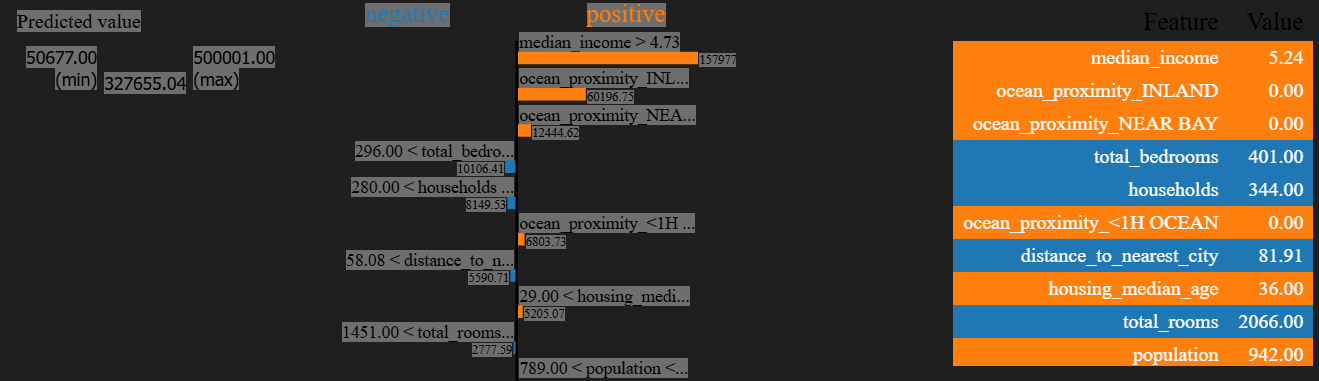

